In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
def make_projectile_data(n=500, noise_std=1.5, seed=42):
    rng = np.random.default_rng(seed)
    v0, g = 25, 9.8          # initial velocity, gravity
    t = np.sort(rng.uniform(0, 2.5, n))     # time samples (s)
    d_true = v0 * t - 0.5 * g * t**2         # true trajectory (physics)
    d_noisy = d_true + rng.normal(0, noise_std, n)  # add measurement noise
    return t, d_noisy, d_true

t, d, d_true = make_projectile_data()

In [8]:
t_train, t_test, d_train, d_test = train_test_split(t,d, test_size=0.3, random_state = 0)

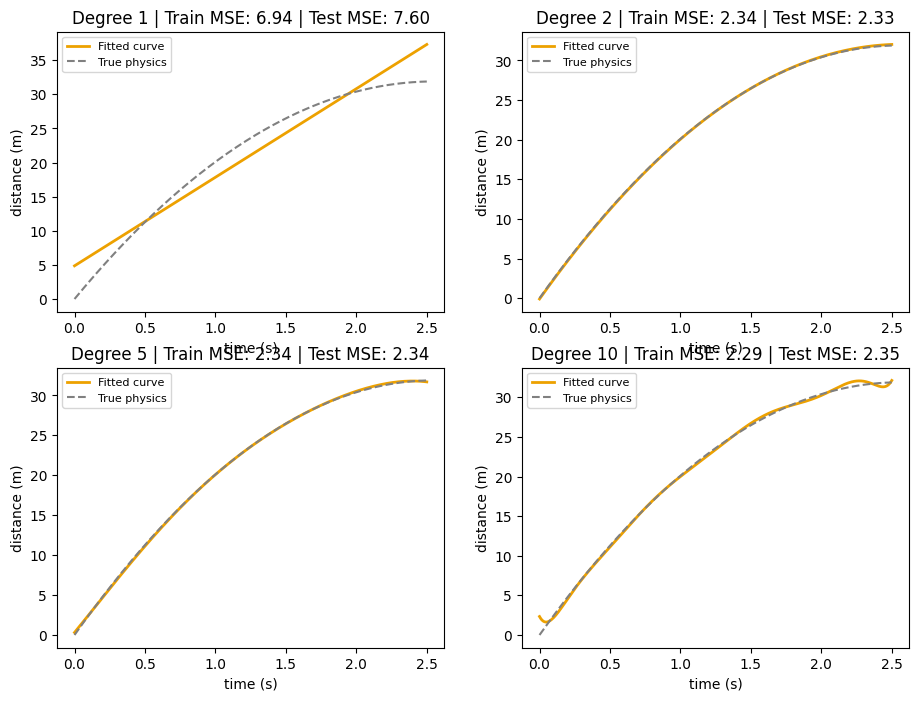

In [ ]:
# For Ploting the fit curve smoothly
t_smooth = np.linspace(0, 2.5, 300).reshape(-1, 1)
d_true_smooth = 25 * t_smooth.ravel() - 0.5 * 9.8 * t_smooth.ravel()**2

degrees = [1, 2, 5, 10]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, degree in zip(axes.ravel(), degrees):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(t_train.reshape(-1, 1))
    X_test_poly = poly.transform(t_test.reshape(-1, 1))
    X_smooth_poly = poly.transform(t_smooth)

    model = LinearRegression()

    model.fit(X_train_poly, d_train)

    train_mse = mean_squared_error(d_train, model.predict(X_train_poly))
    test_mse = mean_squared_error(d_test, model.predict(X_test_poly))
    curve_smooth = model.predict(X_smooth_poly)

    ax.plot(t_smooth, curve_smooth, color='#eda100', linewidth=2, label='Fitted curve')
    ax.plot(t_smooth, d_true_smooth, '--', color='gray', linewidth=1.5, label='True physics')

    ax.set_title(f"Degree {degree} | Train MSE: {train_mse:.2f} | Test MSE: {test_mse:.2f}")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("distance (m)")
    ax.legend(fontsize=8)